# ShoppingClub Sfax — EDA & Modélisation

**Input** : `shoppingclub_cleaned_model_ready.csv` — dataset enrichi, jours fiables uniquement  
**Objectif** : Explorer l'impact des variables sur la fréquentation, puis entraîner et sélectionner le meilleur modèle de prédiction.

**Plan :**
1. Chargement des données
2. EDA — Impact des variables calendaires
3. EDA — Impact de la météo
4. EDA — Corrélations
5. Préparation des features pour la modélisation
6. Benchmark des modèles (TimeSeriesSplit)
7. Sélection et évaluation du meilleur modèle
8. Intervalles de confiance (Quantile Regression)

## 1. Chargement des données


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print("Imports OK")

Imports OK


In [42]:
df = pd.read_csv('/content/shoppingclub_cleaned_model_ready.csv')
df['date'] = pd.to_datetime(df['date'])

# Total visiteurs par jour
daily_visits = df.groupby('date')['Visits'].sum().reset_index()
daily_visits.columns = ['date', 'total_visitors']

# Colonnes météo + flags : identiques par jour → dédupliquer
meta_cols = [
    'date', 'day_status',
    'is_pre_holiday', 'is_post_holiday', 'pre_holiday_name',
    'days_to_next_holiday', 'days_since_last_holiday', 'is_school_holiday',
    'temp_max_c', 'temp_min_c', 'temp_range_c',
    'precipitation_mm', 'wind_kmh', 'humidity_pct',
    'is_rainy', 'heat_stress', 'weather_comfort_score',
]
daily_meta = df[meta_cols].drop_duplicates('date')

# Fusion
daily = daily_visits.merge(daily_meta, on='date', how='left')
daily = daily.sort_values('date').reset_index(drop=True)

# Variables temporelles
daily['day_of_week']  = daily['date'].dt.dayofweek
daily['day_name']     = daily['date'].dt.day_name()
daily['is_weekend']   = (daily['day_of_week'] >= 5).astype(int)
daily['month']        = daily['date'].dt.month
daily['month_name']   = daily['date'].dt.month_name()
daily['week_of_year'] = daily['date'].dt.isocalendar().week.astype(int)
daily['quarter']      = daily['date'].dt.quarter

print(f"Jours : {len(daily)}")
print(f"Période : {daily['date'].min().date()} -> {daily['date'].max().date()}")
print(f"Visiteurs/jour — moy: {daily['total_visitors'].mean():.0f}  "
      f"min: {daily['total_visitors'].min():.0f}  "
      f"max: {daily['total_visitors'].max():.0f}")

Jours : 322
Période : 2025-06-01 -> 2026-05-25
Visiteurs/jour — moy: 2200  min: 913  max: 6902


## 2. EDA — Impact des variables calendaires

On explore comment chaque variable calendaire influence le total journalier de visiteurs.
On travaille sur une vue agrégée **par jour** pour avoir une ligne par date.

### 2.1 Jour de la semaine

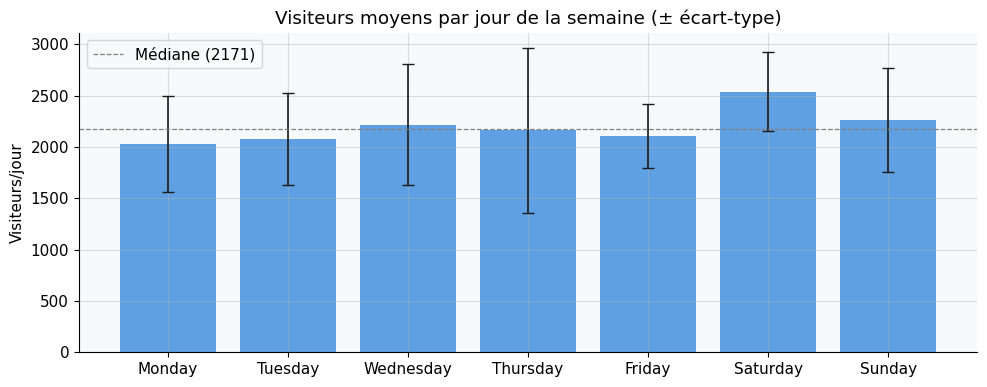

             mean    std
day_name                
Monday     2028.0  467.0
Tuesday    2078.0  449.0
Wednesday  2219.0  593.0
Thursday   2161.0  803.0
Friday     2108.0  311.0
Saturday   2540.0  383.0
Sunday     2265.0  505.0


In [43]:
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = daily.groupby('day_name')['total_visitors'].agg(['mean','std']).reindex(order)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(order, dow['mean'], color='#378ADD', alpha=0.8)
ax.errorbar(order, dow['mean'], yerr=dow['std'],
            fmt='none', color='#1a1a1a', capsize=4, linewidth=1.2)
ax.axhline(daily['total_visitors'].median(), color='gray', linestyle='--',
           linewidth=0.9, label=f"Médiane ({daily['total_visitors'].median():.0f})")
ax.set_title("Visiteurs moyens par jour de la semaine (± écart-type)")
ax.set_ylabel("Visiteurs/jour")
ax.legend()
plt.tight_layout()
plt.show()

print(dow.round(0))

### 2.2 Mois

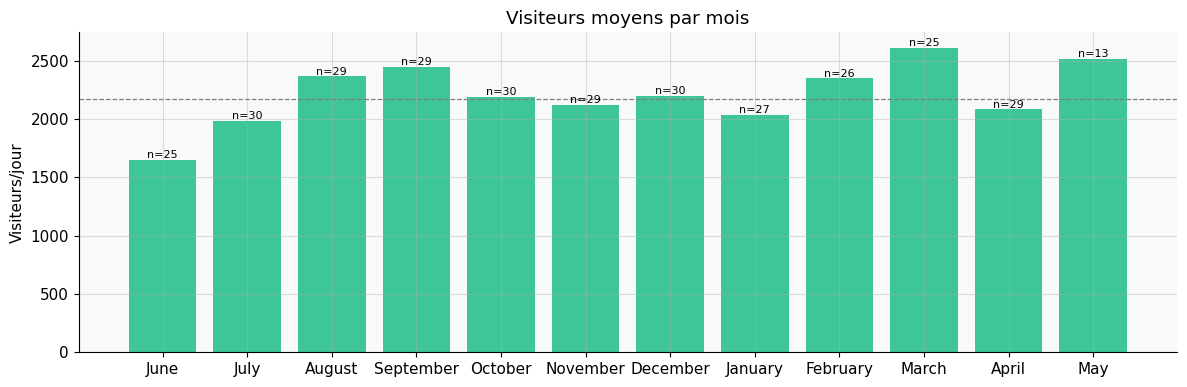

In [44]:
month_order = ['June','July','August','September','October','November',
               'December','January','February','March','April','May']
month_stats = daily.groupby('month_name')['total_visitors'].agg(['mean','count'])
month_stats = month_stats.reindex([m for m in month_order if m in month_stats.index])

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(month_stats.index, month_stats['mean'], color='#10B981', alpha=0.8)
ax.axhline(daily['total_visitors'].median(), color='gray', linestyle='--', linewidth=0.9)
ax.set_title("Visiteurs moyens par mois")
ax.set_ylabel("Visiteurs/jour")
for bar, (_, row) in zip(ax.patches, month_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f"n={int(row['count'])}", ha='center', fontsize=8)
plt.tight_layout()
plt.show()

### 2.3 Effet pré-férié et post-férié

Les jours précédant un jour férié (surtout l'Aïd) présentent des pics très marqués.
On compare la distribution des visites selon ces flags.

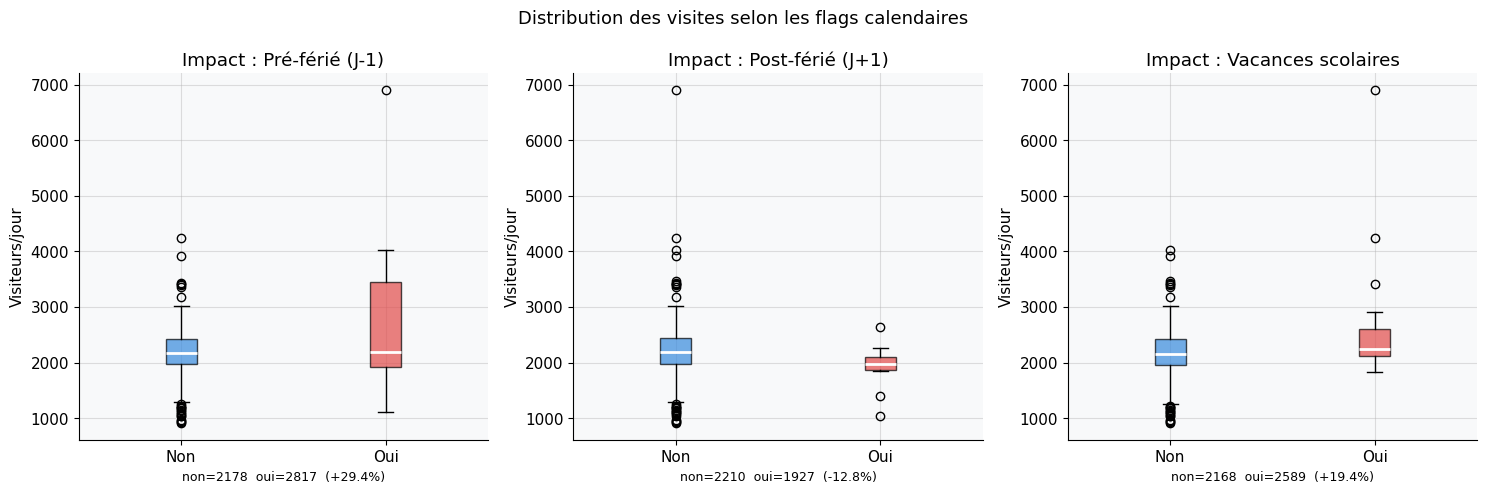

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, title in zip(axes,
    ['is_pre_holiday', 'is_post_holiday', 'is_school_holiday'],
    ['Pré-férié (J-1)', 'Post-férié (J+1)', 'Vacances scolaires']):

    groups = [
        daily[daily[col] == 0]['total_visitors'].dropna(),
        daily[daily[col] == 1]['total_visitors'].dropna(),
    ]
    bp = ax.boxplot(groups, labels=['Non', 'Oui'], patch_artist=True,
                    medianprops=dict(color='white', linewidth=2))
    bp['boxes'][0].set_facecolor('#378ADD')
    bp['boxes'][1].set_facecolor('#E24B4A')
    for patch in bp['boxes']:
        patch.set_alpha(0.7)

    ax.set_title(f"Impact : {title}")
    ax.set_ylabel("Visiteurs/jour")

    m0 = groups[0].mean()
    m1 = groups[1].mean()
    diff = (m1 / m0 - 1) * 100
    ax.set_xlabel(f"non={m0:.0f}  oui={m1:.0f}  ({diff:+.1f}%)", fontsize=9)

plt.suptitle("Distribution des visites selon les flags calendaires", fontsize=13)
plt.tight_layout()
plt.show()

### 2.4 Effet selon le nom du férié (pré-férié uniquement)

L'effet pré-férié n'est pas uniforme : la veille de l'Aïd génère
beaucoup plus de trafic que la veille de la Fête du Travail.

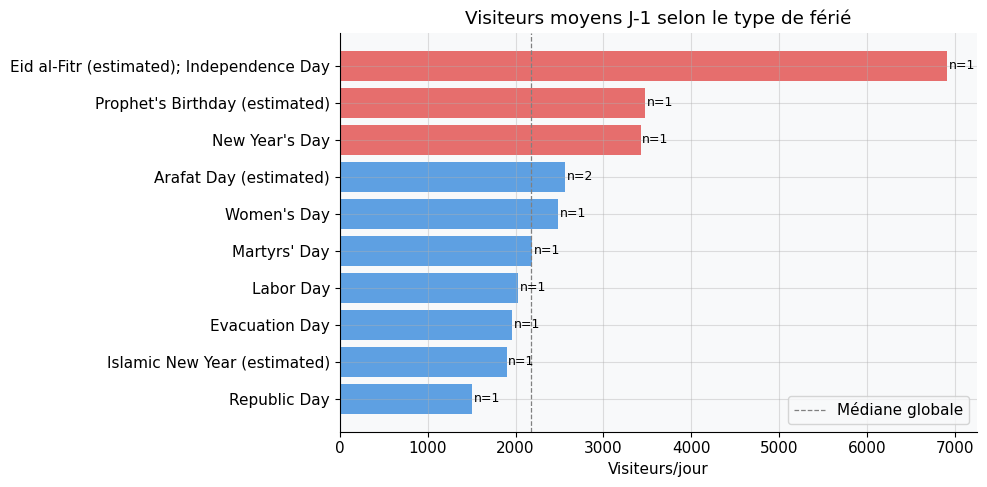

In [46]:
pre_hol = daily[daily['is_pre_holiday'] == 1].copy()
pre_hol_stats = (pre_hol.groupby('pre_holiday_name')['total_visitors']
                 .agg(['mean','count'])
                 .sort_values('mean', ascending=True))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#E24B4A' if v > daily['total_visitors'].median() * 1.5 else '#378ADD'
          for v in pre_hol_stats['mean']]
bars = ax.barh(pre_hol_stats.index, pre_hol_stats['mean'], color=colors, alpha=0.8)
ax.axvline(daily['total_visitors'].median(), color='gray', linestyle='--',
           linewidth=0.9, label='Médiane globale')
ax.set_title("Visiteurs moyens J-1 selon le type de férié")
ax.set_xlabel("Visiteurs/jour")
ax.legend()
for bar, (_, row) in zip(bars, pre_hol_stats.iterrows()):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f"n={int(row['count'])}", va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 3. EDA — Impact de la météo

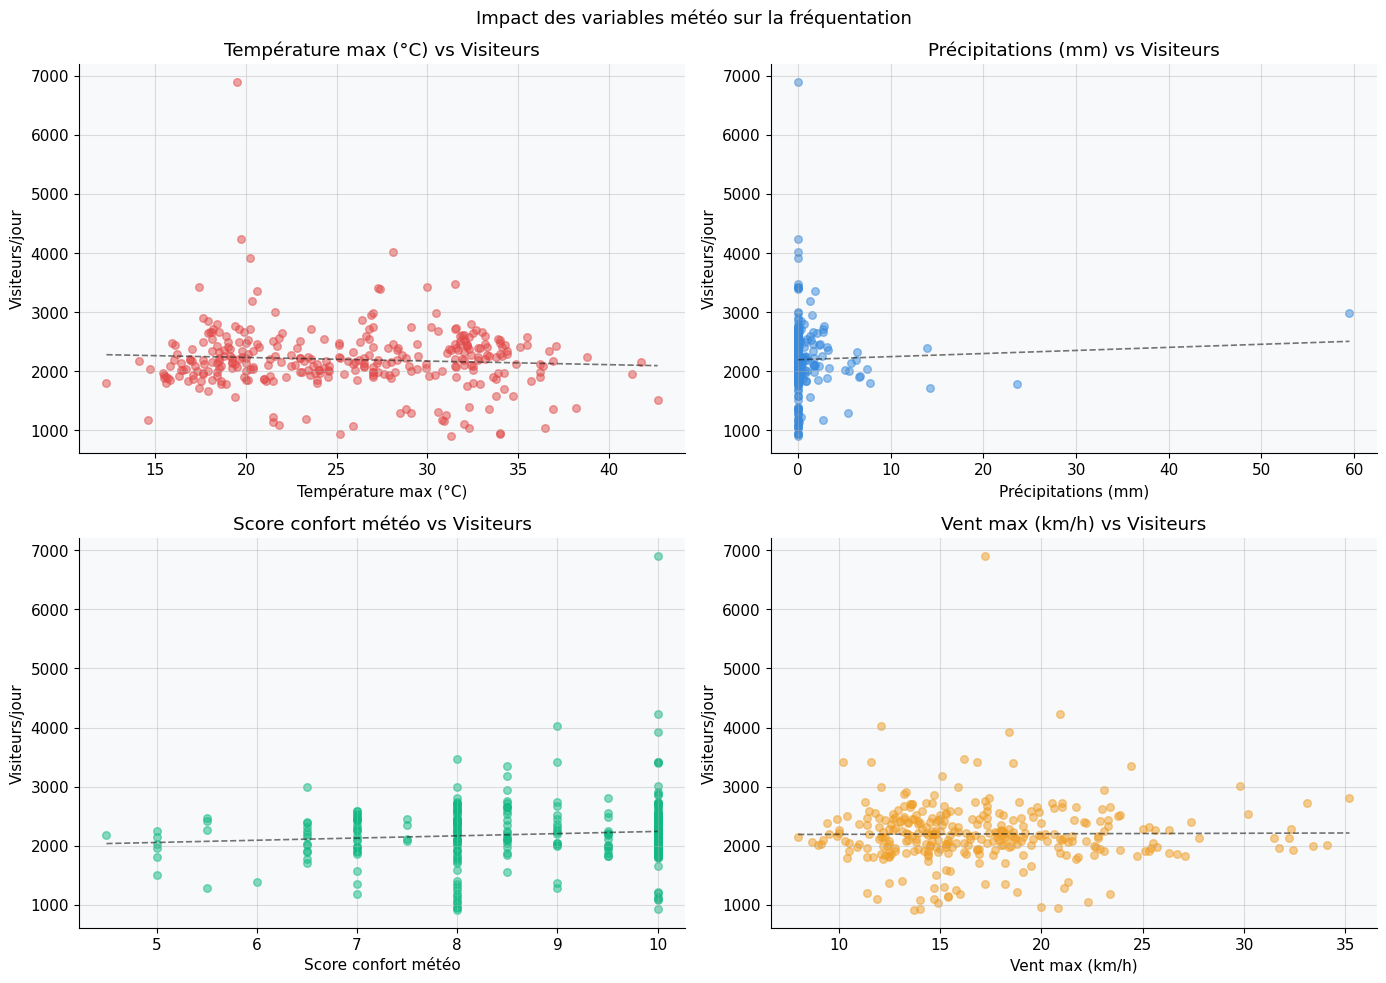

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plots = [
    ('temp_max_c',            'Température max (°C)',   '#E24B4A'),
    ('precipitation_mm',      'Précipitations (mm)',    '#378ADD'),
    ('weather_comfort_score', 'Score confort météo',    '#10B981'),
    ('wind_kmh',              'Vent max (km/h)',         '#EF9F27'),
]

for ax, (col, xlabel, color) in zip(axes.flat, plots):
    ax.scatter(daily[col], daily['total_visitors'],
               color=color, alpha=0.5, s=30)
    # Ligne de tendance
    mask = daily[col].notna()
    z = np.polyfit(daily.loc[mask, col], daily.loc[mask, 'total_visitors'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(daily[col].min(), daily[col].max(), 100)
    ax.plot(x_line, p(x_line), color='#1a1a1a', linewidth=1.2, linestyle='--', alpha=0.6)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Visiteurs/jour")
    ax.set_title(f"{xlabel} vs Visiteurs")

plt.suptitle("Impact des variables météo sur la fréquentation", fontsize=13)
plt.tight_layout()
plt.show()

### 3.1 Visiteurs par catégorie météo

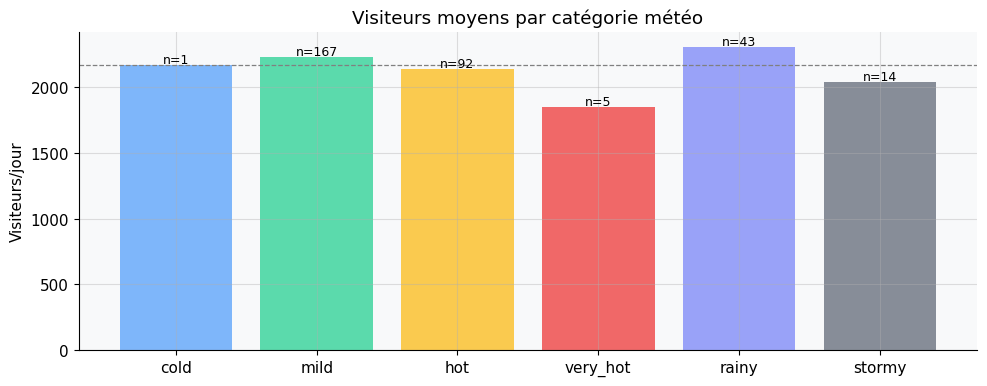

                    mean  count
weather_category               
cold              2168.0      1
mild              2231.0    167
hot               2138.0     92
very_hot          1850.0      5
rainy             2305.0     43
stormy            2036.0     14


In [48]:
# Reconstruire weather_category depuis les données disponibles
def assign_weather_category(row):
    if row['precipitation_mm'] > 5:
        return 'stormy'
    elif row['precipitation_mm'] > 0.5:
        return 'rainy'
    elif row['temp_max_c'] > 38:
        return 'very_hot'
    elif row['temp_max_c'] > 30:
        return 'hot'
    elif row['temp_max_c'] < 15:
        return 'cold'
    else:
        return 'mild'

daily['weather_category'] = daily.apply(assign_weather_category, axis=1)

cat_order  = ['cold', 'mild', 'hot', 'very_hot', 'rainy', 'stormy']
cat_colors = ['#60A5FA','#34D399','#FBBF24','#EF4444','#818CF8','#6B7280']

cat_stats = (daily.groupby('weather_category')['total_visitors']
             .agg(['mean','count'])
             .reindex([c for c in cat_order if c in daily['weather_category'].values]))

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(cat_stats.index,
              cat_stats['mean'],
              color=[cat_colors[cat_order.index(c)] for c in cat_stats.index],
              alpha=0.8)
ax.axhline(daily['total_visitors'].median(), color='gray', linestyle='--', linewidth=0.9)
ax.set_title("Visiteurs moyens par catégorie météo")
ax.set_ylabel("Visiteurs/jour")
for bar, (_, row) in zip(bars, cat_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f"n={int(row['count'])}", ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print(cat_stats.round(0))

## 4. EDA — Corrélations

Matrice de corrélation entre les variables numériques et le total de visiteurs.
Permet d'identifier les features les plus prédictives avant la modélisation.

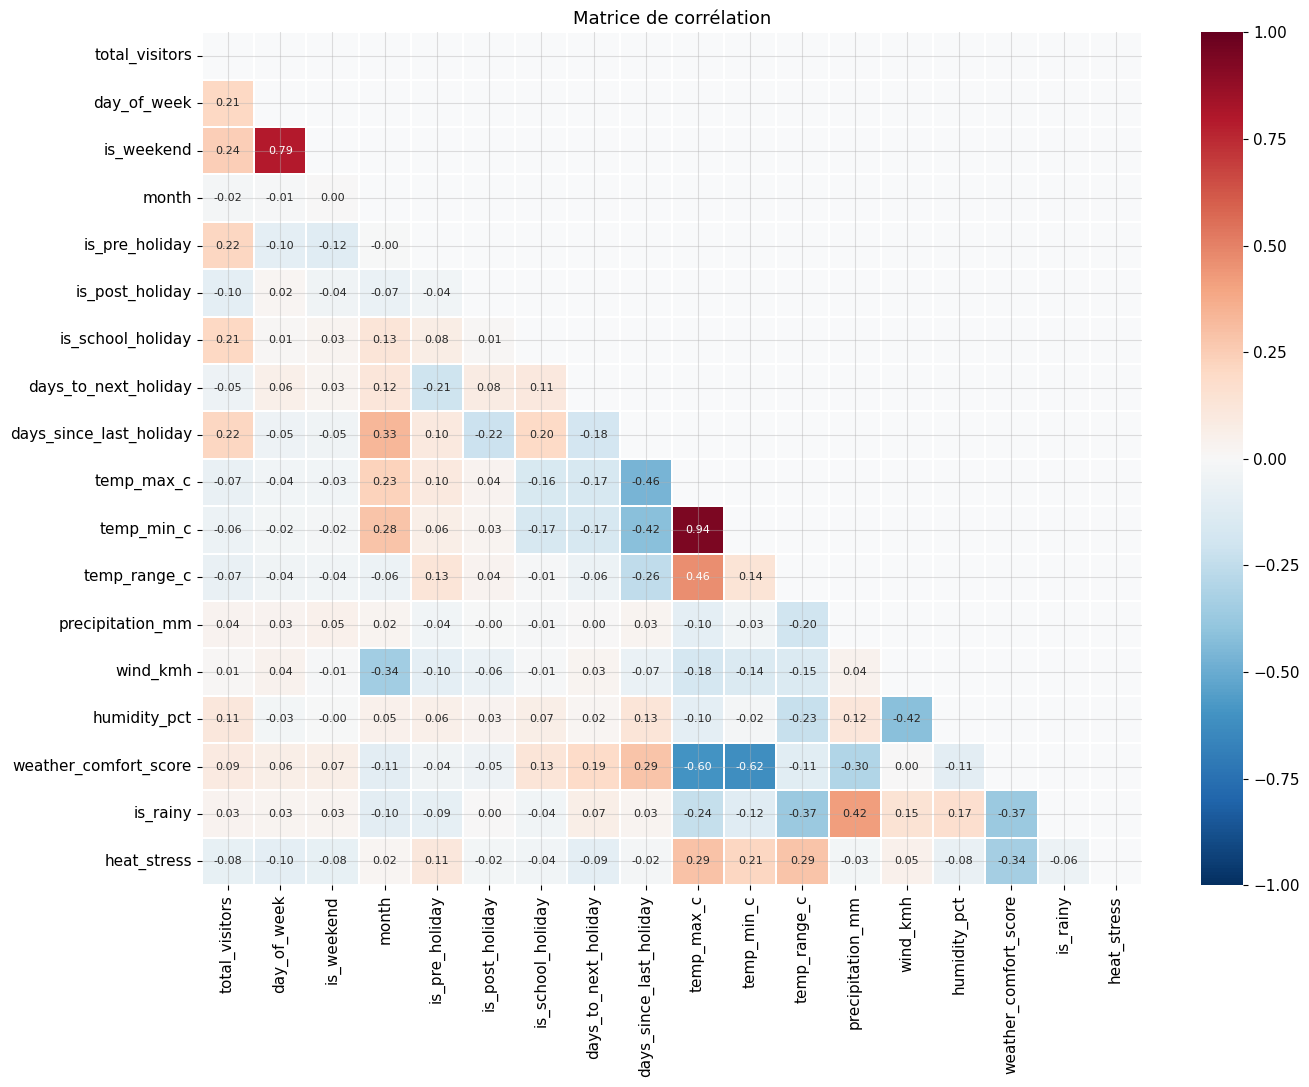

Corrélations avec total_visitors (triées par force) :
is_weekend                 0.242
is_pre_holiday             0.217
days_since_last_holiday    0.217
day_of_week                0.206
is_school_holiday          0.206
humidity_pct               0.114
is_post_holiday           -0.096
weather_comfort_score      0.093
heat_stress               -0.082
temp_max_c                -0.074
temp_range_c              -0.071
temp_min_c                -0.056
days_to_next_holiday      -0.054
precipitation_mm           0.038
is_rainy                   0.034
month                     -0.016
wind_kmh                   0.008
Name: total_visitors, dtype: float64


In [49]:
num_cols = [
    'total_visitors',
    'day_of_week', 'is_weekend', 'month',
    'is_pre_holiday', 'is_post_holiday', 'is_school_holiday',
    'days_to_next_holiday', 'days_since_last_holiday',
    'temp_max_c', 'temp_min_c', 'temp_range_c',
    'precipitation_mm', 'wind_kmh', 'humidity_pct',
    'weather_comfort_score', 'is_rainy', 'heat_stress',
]

corr = daily[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 8}, linewidths=0.3)
ax.set_title("Matrice de corrélation", fontsize=13)
plt.tight_layout()
plt.show()

print("Corrélations avec total_visitors (triées par force) :")
print(corr['total_visitors'].drop('total_visitors')
      .sort_values(key=abs, ascending=False).round(3))

## 5. Préparation des features pour la modélisation

On encode les variables catégorielles et on définit les features d'entrée (X) et la cible (y).
Le split est temporel : les derniers 2 mois constituent le jeu de test.

In [50]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

le = LabelEncoder()
daily['weather_category_enc'] = le.fit_transform(daily['weather_category'].astype(str))
daily['pre_holiday_name_enc'] = le.fit_transform(
    daily['pre_holiday_name'].fillna('none').astype(str)
)

FEATURES = [
    'day_of_week', 'is_weekend', 'month', 'week_of_year', 'quarter',
    'is_pre_holiday', 'is_post_holiday', 'is_school_holiday',
    'pre_holiday_name_enc',
    'days_to_next_holiday', 'days_since_last_holiday',
    'temp_max_c', 'temp_min_c', 'temp_range_c',
    'precipitation_mm', 'wind_kmh', 'humidity_pct',
    'weather_comfort_score', 'is_rainy', 'heat_stress',
    'weather_category_enc',
]
TARGET = 'total_visitors'

cutoff = daily['date'].max() - pd.DateOffset(months=2)
train  = daily[daily['date'] <= cutoff]
test   = daily[daily['date'] >  cutoff]

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f"Train : {len(train)} jours ({train['date'].min().date()} -> {train['date'].max().date()})")
print(f"Test  : {len(test)} jours ({test['date'].min().date()} -> {test['date'].max().date()})")
print(f"Features : {len(FEATURES)}")

Train : 274 jours (2025-06-01 -> 2026-03-25)
Test  : 48 jours (2026-03-26 -> 2026-05-25)
Features : 21


## 6. Benchmark des modèles

On compare plusieurs modèles avec une validation croisée temporelle (TimeSeriesSplit).
Métriques retenues : MAE, RMSE, R².

In [51]:
tscv = TimeSeriesSplit(n_splits=5)

MODELS = {
    'LightGBM':         LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42, verbose=-1),
    'XGBoost':          XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42, verbosity=0),
    'RandomForest':     RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'ExtraTrees':       ExtraTreesRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42),
    'Ridge':            Ridge(alpha=1.0),
}

results = {}
for name, model in MODELS.items():
    cv = cross_validate(model, X_train, y_train, cv=tscv,
                        scoring=['neg_mean_absolute_error',
                                 'neg_root_mean_squared_error', 'r2'])
    results[name] = {
        'MAE':  -cv['test_neg_mean_absolute_error'].mean(),
        'RMSE': -cv['test_neg_root_mean_squared_error'].mean(),
        'R2':    cv['test_r2'].mean(),
    }
    print(f"{name:20} | MAE: {results[name]['MAE']:7.1f} | "
          f"RMSE: {results[name]['RMSE']:7.1f} | R²: {results[name]['R2']:.3f}")

results_df = pd.DataFrame(results).T.sort_values('MAE')

LightGBM             | MAE:   418.2 | RMSE:   563.3 | R²: -0.475
XGBoost              | MAE:   505.5 | RMSE:   686.9 | R²: -1.286
RandomForest         | MAE:   483.9 | RMSE:   636.4 | R²: -0.961
ExtraTrees           | MAE:   488.9 | RMSE:   632.2 | R²: -0.880
GradientBoosting     | MAE:   549.4 | RMSE:   703.9 | R²: -1.601
Ridge                | MAE:   960.8 | RMSE:  1180.5 | R²: -8.135


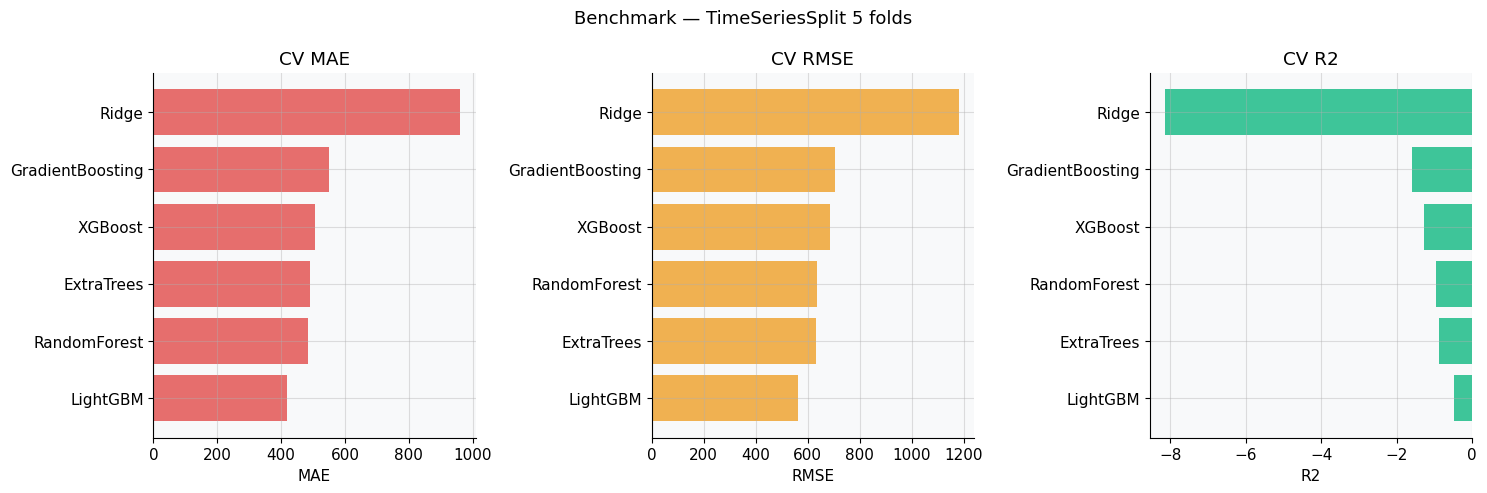


Classement final :
                     MAE     RMSE    R2
LightGBM          418.21   563.35 -0.47
RandomForest      483.86   636.40 -0.96
ExtraTrees        488.94   632.23 -0.88
XGBoost           505.51   686.88 -1.29
GradientBoosting  549.39   703.86 -1.60
Ridge             960.84  1180.52 -8.14


In [52]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric, color in zip(axes,
    ['MAE', 'RMSE', 'R2'],
    ['#E24B4A', '#EF9F27', '#10B981']):
    vals = results_df[metric].sort_values(ascending=(metric != 'R2'))
    ax.barh(vals.index, vals.values, color=color, alpha=0.8)
    ax.set_title(f"CV {metric}")
    ax.set_xlabel(metric)

plt.suptitle("Benchmark — TimeSeriesSplit 5 folds", fontsize=13)
plt.tight_layout()
plt.show()

print("\nClassement final :")
print(results_df.round(2))

## 7. Évaluation du meilleur modèle

On retient le modèle avec le meilleur MAE en CV, on l'entraîne sur tout le train
et on évalue sur le jeu de test.

In [53]:
best_name  = results_df['MAE'].idxmin()
best_model = MODELS[best_name]
print(f"Meilleur modèle : {best_name}\n")

best_model.fit(X_train, y_train)
y_pred = np.maximum(best_model.predict(X_test), 0)

mae   = mean_absolute_error(y_test, y_pred)
rmse  = np.sqrt(mean_squared_error(y_test, y_pred))
r2    = 1 - np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2)
smape = np.mean(2 * np.abs(y_pred - y_test) /
                (np.abs(y_pred) + np.abs(y_test) + 1e-8)) * 100

print(f"MAE   : {mae:.1f} visiteurs")
print(f"RMSE  : {rmse:.1f}")
print(f"R²    : {r2:.3f}")
print(f"sMAPE : {smape:.1f}%")

Meilleur modèle : LightGBM

MAE   : 444.4 visiteurs
RMSE  : 673.3
R²    : -0.883
sMAPE : 20.7%


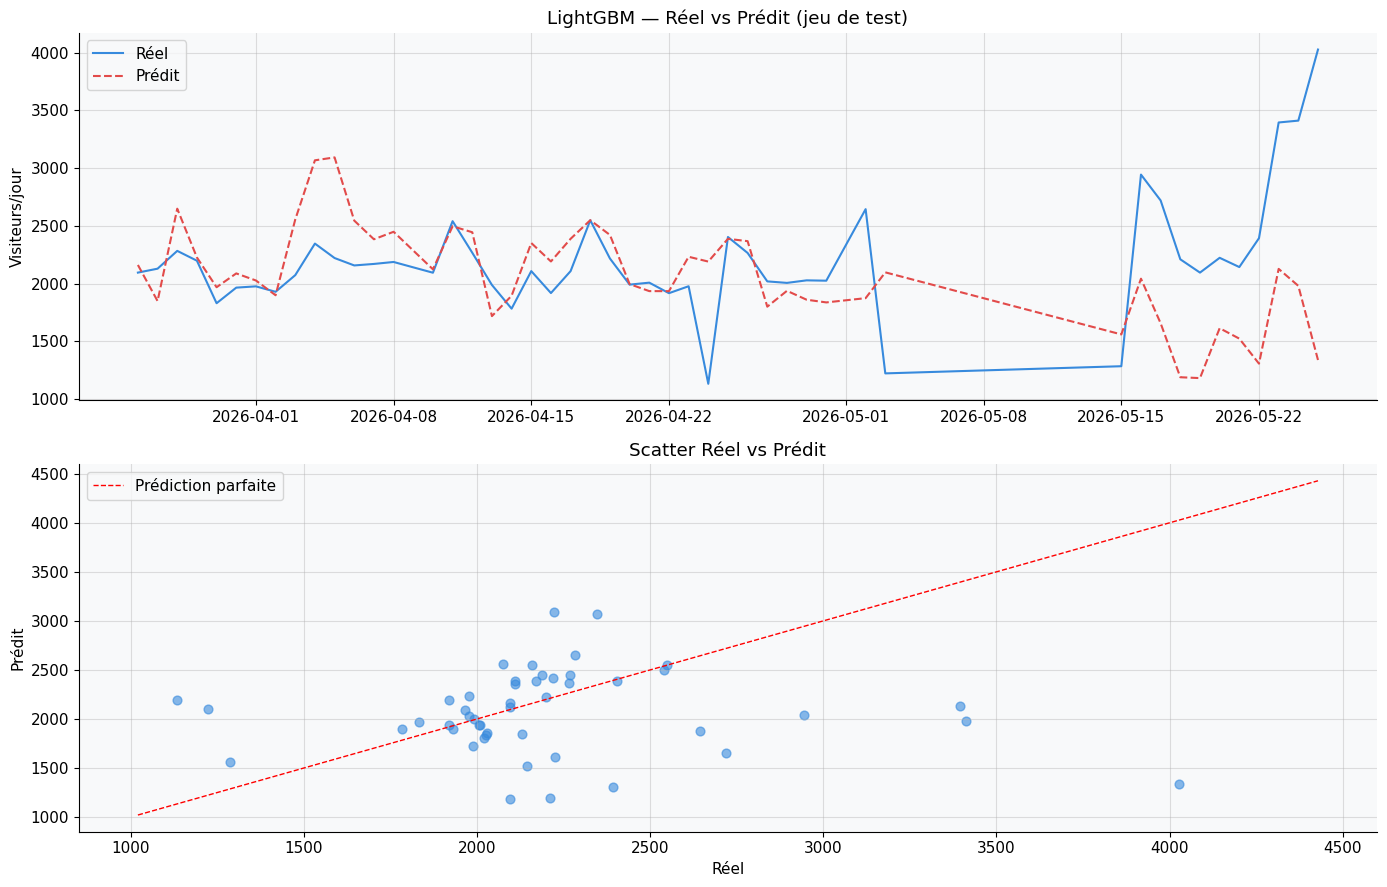

In [54]:
#Prediction plots
results_test = test[['date', TARGET]].copy()
results_test['predicted'] = y_pred

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

ax = axes[0]
ax.plot(results_test['date'], results_test[TARGET],
        label='Réel', color='#378ADD', linewidth=1.5)
ax.plot(results_test['date'], results_test['predicted'],
        label='Prédit', color='#E24B4A', linewidth=1.5, linestyle='--')
ax.set_title(f"{best_name} — Réel vs Prédit (jeu de test)")
ax.set_ylabel("Visiteurs/jour")
ax.legend()

ax = axes[1]
ax.scatter(results_test[TARGET], results_test['predicted'],
           alpha=0.6, color='#378ADD', s=40)
lims = [min(y_test.min(), y_pred.min()) * 0.9,
        max(y_test.max(), y_pred.max()) * 1.1]
ax.plot(lims, lims, 'r--', linewidth=1, label='Prédiction parfaite')
ax.set_xlabel("Réel")
ax.set_ylabel("Prédit")
ax.set_title("Scatter Réel vs Prédit")
ax.legend()

plt.tight_layout()
plt.show()

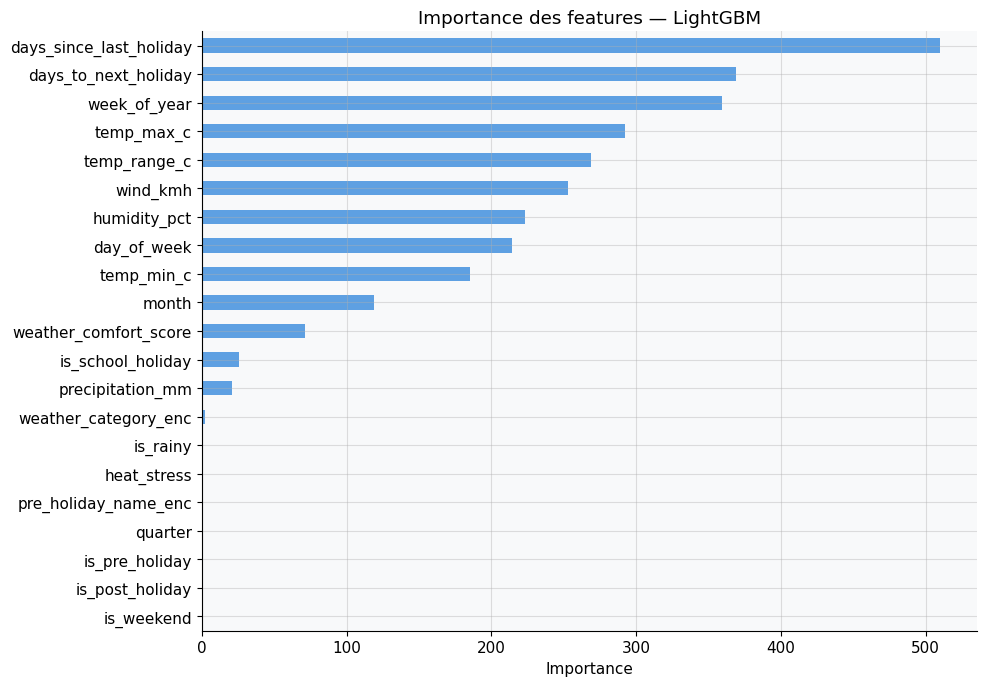

In [55]:
# Feature importance
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_,
                   index=FEATURES).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(10, 7))
    fi.plot(kind='barh', ax=ax, color='#378ADD', alpha=0.8)
    ax.set_title(f"Importance des features — {best_name}")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.show()

## 8. Intervalles de confiance (Quantile Regression)

On entraîne deux modèles supplémentaires pour obtenir une borne basse (10e percentile)
et une borne haute (90e percentile), donnant un intervalle de confiance à 80%.

Couverture empirique (cible 80%) : 68.8%
Largeur moyenne de l'intervalle  : 699 visiteurs


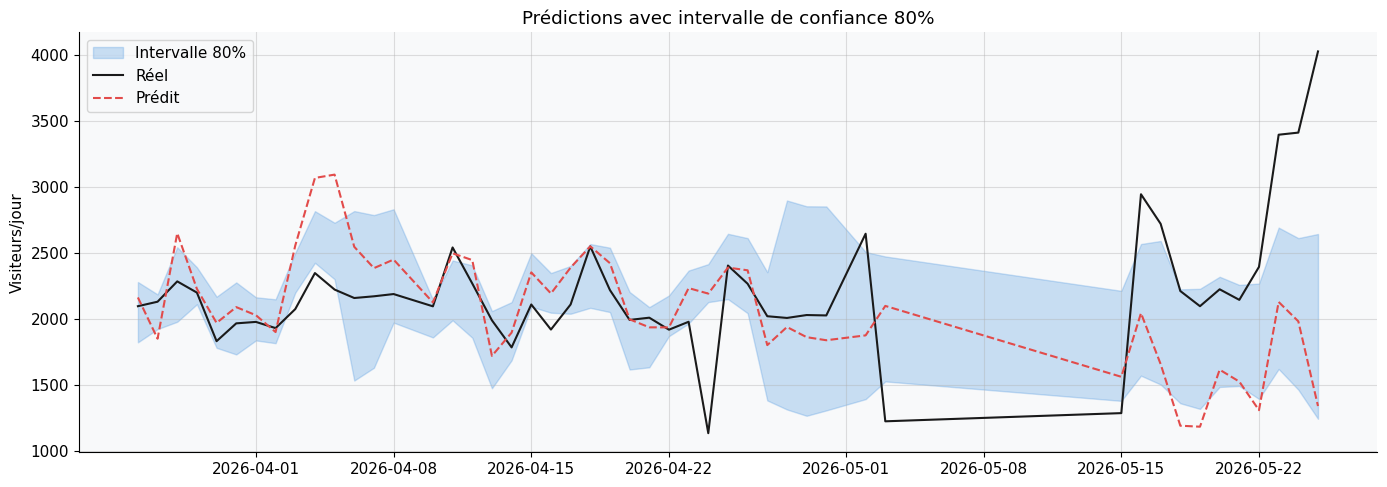

In [56]:
model_low  = LGBMRegressor(objective='quantile', alpha=0.10,
                            n_estimators=300, learning_rate=0.05,
                            random_state=42, verbose=-1)
model_high = LGBMRegressor(objective='quantile', alpha=0.90,
                            n_estimators=300, learning_rate=0.05,
                            random_state=42, verbose=-1)

model_low.fit(X_train, y_train)
model_high.fit(X_train, y_train)

lower = np.maximum(model_low.predict(X_test), 0)
upper = np.maximum(model_high.predict(X_test), 0)

coverage = ((y_test.values >= lower) & (y_test.values <= upper)).mean()
print(f"Couverture empirique (cible 80%) : {coverage:.1%}")
print(f"Largeur moyenne de l'intervalle  : {(upper - lower).mean():.0f} visiteurs")

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(results_test['date'], lower, upper,
                alpha=0.25, color='#378ADD', label="Intervalle 80%")
ax.plot(results_test['date'], results_test[TARGET],
        color='#1a1a1a', linewidth=1.5, label='Réel')
ax.plot(results_test['date'], results_test['predicted'],
        color='#E24B4A', linewidth=1.5, linestyle='--', label='Prédit')
ax.set_title("Prédictions avec intervalle de confiance 80%")
ax.set_ylabel("Visiteurs/jour")
ax.legend()
plt.tight_layout()
plt.show()

In [57]:
import joblib
from google.colab import files

# Train the best model on the full dataset (train + test)
best_model.fit(X_train, y_train)

# Save it
joblib.dump(best_model, 'lightgbm_shoppingclub.pkl')

# Download it
files.download('lightgbm_shoppingclub.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>